This script calculates the moments of the images using a series of named techniques 
<br> Reads image stack and writes to moments DataFrame


## User Input
Choose which dataset to work on

In [ ]:
%run -i ../src/General_Data/Analysis/Data_Classes.py
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_571.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_571.return_params()
# # pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_571.return_params()
# # pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = June_2024_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = October_2024_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_241.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_571.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_571_smoke.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_241.return_params()


## Import Statements

In [2]:
import numpy as np
import os
import concurrent
import pandas as pd
from Image_Analysis import *
from scipy import stats
from scipy.ndimage import median_filter


In [3]:
%run -i Image_Analysis.py

## Manipulate Inputs

In [4]:
screen_nickname = screen.split(':')[2]
os.makedirs(save_loc, exist_ok=True)

## Load data

In [5]:
all_images = np.load(save_loc + 'all_images_stack_' + screen_nickname + '.npy')
bg_cropp = np.load(save_loc + 'background_' + screen_nickname + '.npy')
all_data = pd.read_pickle(save_loc + 'all_data_stack_' + screen_nickname + '.pkl')

In [6]:
all_data

,SOLN:IN10:121:BACT,SOLN:IN10:111:BACT,QUAD:IN10:121:BACT,QUAD:IN10:122:BACT,QUAD:IN10:361:BACT,QUAD:IN10:371:BACT,QUAD:IN10:425:BACT,QUAD:IN10:441:BACT,QUAD:IN10:511:BACT,QUAD:IN10:525:BACT,...,PROF:IN10:571:RESOLUTION,PROF:IN10:711:Image:ArrayData,PROF:IN10:711:XRMS,PROF:IN10:711:YRMS,PROF:IN10:711:Image:ArraySize1_RBV,PROF:IN10:711:Image:ArraySize0_RBV,PROF:IN10:711:X,PROF:IN10:711:Y,PROF:IN10:711:RESOLUTION,timestamp


## Pixel Calibration

In [7]:
pxcal = pd.unique(all_data[screen.split('Image:')[0] + 'RESOLUTION']).astype(float)
pxcal = pxcal[~np.isnan(pxcal)]
if len(pxcal)>1:
    raise ValueError("more than one pixel calibration")
else:
    pxcal = float(pxcal)

TypeError: only length-1 arrays can be converted to Python scalars

## Background Subtract Image Analysis

In [8]:
moments = pd.DataFrame({})

In [9]:
def safe_extract(fit):
    try:
        s = fit.Sigma
    except:
        s = np.nan
    return s

def rms_extractor(x):
    """
    Returns a numpy array of moments given a list of GaussianParams objects
    
    Argument:
    x -- a list of GaussianParams objects
    """
    try: x = list(x)
    except: raise ValueError("Input could not be converted to a list")
    assert isinstance(x,list)==True, "input is not a list!"
    
    return np.array([safe_extract(i) for i in list(x)])

In [10]:

all_img_list_bg_subt = [all_images[i,:,:]-bg_cropp for i in range(len(all_images))]
all_img_med_bg_subt = [median_filter(all_images[i,:,:]-bg_cropp,size=3) for i in range(len(all_images))]

# all_img_list_bg_subt = []
# for img in all_img_list_bg_subt1:
#     img[img<0] = 0
#     all_img_list_bg_subt.append(img)

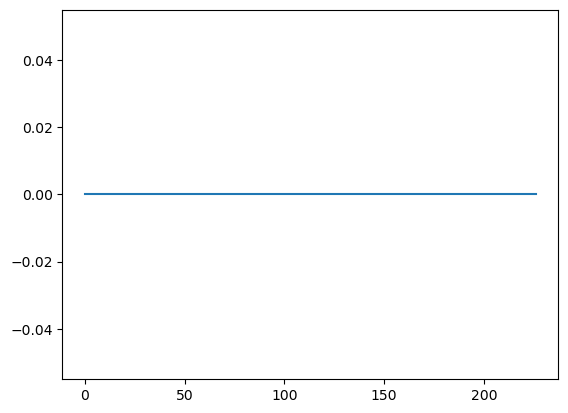

In [11]:
# plt.imshow(all_img_list_bg_subt[0])
# plt.colorbar()
plt.plot(np.sum(all_img_list_bg_subt[0],axis=0))

In [12]:
%%time
nickname = 'Gauss-BG-Subt'
with concurrent.futures.ProcessPoolExecutor() as pool:
    xfit_Gauss, yfit_Gauss,xfit45_Gauss,yfit45_Gauss = zip(*pool.map(Gaussian_Fit_4_Dim, all_img_list_bg_subt))
moments['x_'+nickname] = np.array(rms_extractor(xfit_Gauss))*pxcal
moments['y_'+nickname] = np.array(rms_extractor(yfit_Gauss))*pxcal
moments['x45_'+nickname] = np.array(rms_extractor(xfit45_Gauss))*pxcal
moments['y45_'+nickname] = np.array(rms_extractor(yfit45_Gauss))*pxcal

CPU times: user 107 ms, sys: 3.14 s, total: 3.25 s
Wall time: 3.66 s


In [13]:
# %%time
# nickname = 'RMS-BG-Subt'
# # all_img_list_bg_subt = [all_images[i,:,:]-bg_cropp for i in range(len(all_images))]
# def func(img):
#     xfit, yfit,xfit45,yfit45 = RMS_Image_Analysis(img)
#     return xfit, yfit,xfit45,yfit45
# with concurrent.futures.ProcessPoolExecutor() as pool:
#     xfit_RMS, yfit_RMS,xfit45_RMS,yfit45_RMS = zip(*pool.map(func, all_img_list_bg_subt))
# moments['x_'+nickname] = np.array(rms_extractor(xfit_RMS))*pxcal
# moments['y_'+nickname] = np.array(rms_extractor(yfit_RMS))*pxcal
# moments['x45_'+nickname] = np.array(rms_extractor(xfit45_RMS))*pxcal
# moments['y45_'+nickname] = np.array(rms_extractor(yfit45_RMS))*pxcal

In [14]:
# %%time
# import warnings
# warnings.filterwarnings('ignore')
# nickname = 'RMS-BG-Subt-thresh3'
# all_img_list_bg_subt = [all_images[i,:,:]-bg_cropp for i in range(len(all_images))]
# def func(img):
#     xfit, yfit,xfit45,yfit45 = RMS_img_Analysis_thresh(img,n_sigma=3)
#     return xfit, yfit,xfit45,yfit45
# with concurrent.futures.ProcessPoolExecutor() as pool:
#     xfit, yfit,xfit45,yfit45 = zip(*pool.map(func, all_img_list_bg_subt))
# moments['x_'+nickname] = np.array(rms_extractor(xfit))*pxcal
# moments['y_'+nickname] = np.array(rms_extractor(yfit))*pxcal
# moments['x45_'+nickname] = np.array(rms_extractor(xfit45))*pxcal
# moments['y45_'+nickname] = np.array(rms_extractor(yfit45))*pxcal

In [15]:
# %%time
# import warnings
# warnings.filterwarnings('ignore')
# nickname = 'RMS-BG-Subt-med-filt3'
# all_img_list_bg_subt = [median_filter(all_images[i,:,:], size=3) for i in range(len(all_images))]
# def func(img):
#     xfit, yfit,xfit45,yfit45 = RMS_Image_Analysis(img)
#     return xfit, yfit,xfit45,yfit45
# with concurrent.futures.ProcessPoolExecutor() as pool:
#     xfit, yfit,xfit45,yfit45 = zip(*pool.map(func, all_img_list_bg_subt))
# moments['x_'+nickname] = np.array(rms_extractor(xfit))*pxcal
# moments['y_'+nickname] = np.array(rms_extractor(yfit))*pxcal
# moments['x45_'+nickname] = np.array(rms_extractor(xfit45))*pxcal
# moments['y45_'+nickname] = np.array(rms_extractor(yfit45))*pxcal

In [16]:
# %%time
# nickname = 'RMS-BG-Subt-med-filt'
# all_img_list_bg_subt = [median_filter(all_images[i,:,:]-bg_cropp, size=3) for i in range(len(all_images))]
# def func(img):
#     xfit, yfit,xfit45,yfit45 = RMS_img_Analysis_thresh(img,n_sigma=0)
#     return xfit, yfit,xfit45,yfit45
# with concurrent.futures.ProcessPoolExecutor() as pool:
#     xfit, yfit,xfit45,yfit45 = zip(*pool.map(func, all_img_list_bg_subt))
# moments['x_'+nickname] = np.array(rms_extractor(xfit))*pxcal
# moments['y_'+nickname] = np.array(rms_extractor(yfit))*pxcal
# moments['x45_'+nickname] = np.array(rms_extractor(xfit45))*pxcal
# moments['y45_'+nickname] = np.array(rms_extractor(yfit45))*pxcal

In [17]:
%%time
nickname = 'BG-med-Gauss-RMS'
import warnings
warnings.filterwarnings('ignore')
# all_img_list_bg_subt = [all_images[i,:,:]-bg_cropp for i in range(len(all_images))]
def func(img):
    try:
        xfit, yfit,xfit45,yfit45,img = image_analysis_5(img,initial_Gauss=True,return_images=True)
    except:
        xfit = np.nan
        yfit = np.nan
        xfit45 = np.nan
        yfit45 = np.nan
        img = np.nan
    return xfit, yfit,xfit45,yfit45,img
with concurrent.futures.ProcessPoolExecutor() as pool:
    xfit, yfit,xfit45,yfit45,img_array = zip(*pool.map(func, all_img_med_bg_subt))
moments['x_'+nickname] = np.array(rms_extractor(xfit))*pxcal
moments['y_'+nickname] = np.array(rms_extractor(yfit))*pxcal
moments['x45_'+nickname] = np.array(rms_extractor(xfit45))*pxcal
moments['y45_'+nickname] = np.array(rms_extractor(yfit45))*pxcal

CPU times: user 114 ms, sys: 3.24 s, total: 3.36 s
Wall time: 3.65 s


In [18]:
%%time
nickname = 'BG-med-Gauss-RMS-6'
import warnings
warnings.filterwarnings('ignore')
# all_img_list_bg_subt = [all_images[i,:,:]-bg_cropp for i in range(len(all_images))]
def func(img):
    try:
        xfit, yfit,xfit45,yfit45,img = image_analysis_6(img,initial_Gauss=True,return_images=True)
    except:
        xfit = np.nan
        yfit = np.nan
        xfit45 = np.nan
        yfit45 = np.nan
        img = np.nan
    return xfit, yfit,xfit45,yfit45,img
with concurrent.futures.ProcessPoolExecutor() as pool:
    xfit, yfit,xfit45,yfit45,img_array = zip(*pool.map(func, all_img_med_bg_subt))
moments['x_'+nickname] = np.array(rms_extractor(xfit))*pxcal
moments['y_'+nickname] = np.array(rms_extractor(yfit))*pxcal
moments['x45_'+nickname] = np.array(rms_extractor(xfit45))*pxcal
moments['y45_'+nickname] = np.array(rms_extractor(yfit45))*pxcal

CPU times: user 108 ms, sys: 3.4 s, total: 3.51 s
Wall time: 3.79 s


In [19]:
# %%time
# nickname = 'BG-med-RMS-RMS'
# # all_img_list_bg_subt = [all_images[i,:,:]-bg_cropp for i in range(len(all_images))]
# def func(img):
#     try:
#         xfit, yfit,xfit45,yfit45 = image_analysis_5(img,initial_Gauss=False)
#     except:
#         xfit = np.nan
#         yfit = np.nan
#         xfit45 = np.nan
#         yfit45 = np.nan
#     return xfit, yfit,xfit45,yfit45
# with concurrent.futures.ProcessPoolExecutor() as pool:
#     xfit, yfit,xfit45,yfit45 = zip(*pool.map(func, all_img_list_bg_subt))
# moments['x_'+nickname] = np.array(rms_extractor(xfit))*pxcal
# moments['y_'+nickname] = np.array(rms_extractor(yfit))*pxcal
# moments['x45_'+nickname] = np.array(rms_extractor(xfit45))*pxcal
# moments['y45_'+nickname] = np.array(rms_extractor(yfit45))*pxcal

## Check and save moments

In [20]:
moments

,x_Gauss-BG-Subt,y_Gauss-BG-Subt,x45_Gauss-BG-Subt,y45_Gauss-BG-Subt,x_BG-med-Gauss-RMS,y_BG-med-Gauss-RMS,x45_BG-med-Gauss-RMS,y45_BG-med-Gauss-RMS,x_BG-med-Gauss-RMS-6,y_BG-med-Gauss-RMS-6,x45_BG-med-Gauss-RMS-6,y45_BG-med-Gauss-RMS-6
0,162.8952,109.7928,162.8952,109.7928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,162.8952,109.7928,162.8952,109.7928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,162.8952,109.7928,162.8952,109.7928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
row_has_nan = moments.isnull().any(axis=1)

In [22]:
moments_cleaned = moments.loc[~row_has_nan].reset_index(drop=True)
images = all_images[~row_has_nan,:,:]
data = all_data[~row_has_nan].reset_index(drop=True)

In [23]:
moments_cleaned

,x_Gauss-BG-Subt,y_Gauss-BG-Subt,x45_Gauss-BG-Subt,y45_Gauss-BG-Subt,x_BG-med-Gauss-RMS,y_BG-med-Gauss-RMS,x45_BG-med-Gauss-RMS,y45_BG-med-Gauss-RMS,x_BG-med-Gauss-RMS-6,y_BG-med-Gauss-RMS-6,x45_BG-med-Gauss-RMS-6,y45_BG-med-Gauss-RMS-6


In [24]:
data

,SOLN:IN10:121:BACT,SOLN:IN10:111:BACT,QUAD:IN10:121:BACT,QUAD:IN10:122:BACT,QUAD:IN10:361:BACT,QUAD:IN10:371:BACT,QUAD:IN10:425:BACT,QUAD:IN10:441:BACT,QUAD:IN10:511:BACT,QUAD:IN10:525:BACT,...,PROF:IN10:571:RESOLUTION,PROF:IN10:711:Image:ArrayData,PROF:IN10:711:XRMS,PROF:IN10:711:YRMS,PROF:IN10:711:Image:ArraySize1_RBV,PROF:IN10:711:Image:ArraySize0_RBV,PROF:IN10:711:X,PROF:IN10:711:Y,PROF:IN10:711:RESOLUTION,timestamp


In [25]:
moments_cleaned.to_hdf(save_loc + 'moments' + screen_nickname + '.h5','moments')
np.save(save_loc + 'all_images_stack_' + screen_nickname + '.npy',images)
data.to_pickle(save_loc + 'all_data_stack_' + screen_nickname + '.pkl')

In [26]:
import pandas as pd
test = pd.read_hdf(save_loc + 'moments' + screen_nickname + '.h5')
test

,x_Gauss-BG-Subt,y_Gauss-BG-Subt,x45_Gauss-BG-Subt,y45_Gauss-BG-Subt,x_BG-med-Gauss-RMS,y_BG-med-Gauss-RMS,x45_BG-med-Gauss-RMS,y45_BG-med-Gauss-RMS,x_BG-med-Gauss-RMS-6,y_BG-med-Gauss-RMS-6,x45_BG-med-Gauss-RMS-6,y45_BG-med-Gauss-RMS-6


In [27]:
save_loc + 'moments' + screen_nickname + '.h5'

'/global/homes/c/cropp/cropp/Generic_Processed_Data//2025-05-28-test/moments241.h5'

## Plot

In [28]:
unq_cols = []
for col in list(moments.columns):
    col_trunc = col.split('_')[-1]
    unq_cols.append(col_trunc)
unq_cols = np.unique(np.array(unq_cols))

In [29]:
def zscore(series):
    series = np.array(series.to_list())
    return np.abs(stats.zscore(series))
def outlier_detect(zscores,thresh):
    return  (zscores > thresh)

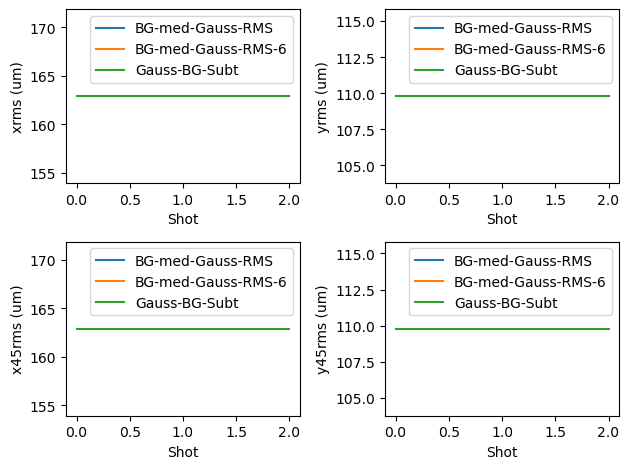

In [30]:
fig,ax=plt.subplots(2,2)
for col in list(unq_cols):
    data1 = moments['x_'+ col]
    data2 = moments['y_'+ col]
    data3 = moments['x45_'+ col]
    data4 = moments['y45_'+ col]
    
    # fig.suptitle(col)
    ax[0,0].plot(data1,label=col)
    # ax[0,0].set_title('x')
    ax[0,0].set_xlabel('Shot')
    ax[0,0].set_ylabel('xrms (um)')
    ax[0,0].legend()
    
    ax[0,1].plot(data2,label=col)
    # ax[0,1].set_title('x')
    ax[0,1].set_xlabel('Shot')
    ax[0,1].set_ylabel('yrms (um)')
    ax[0,1].legend()
    
    ax[1,0].plot(data3,label=col)
    # ax[1,0].set_title('x')
    ax[1,0].set_xlabel('Shot')
    ax[1,0].set_ylabel('x45rms (um)')
    ax[1,0].legend()
    
    ax[1,1].plot(data4,label=col)
    # ax[1,1].set_title('x')
    ax[1,1].set_xlabel('Shot')
    ax[1,1].set_ylabel('y45rms (um)')
    ax[1,1].legend()
plt.tight_layout()

In [31]:
# cutoff = 750
# test1 = moments['x_RMS-BG-Subt-thresh3']
# test2 = moments['y_RMS-BG-Subt-thresh3']
# test3 = moments['x45_RMS-BG-Subt-thresh3']
# test4 = moments['y45_RMS-BG-Subt-thresh3']

# idx1 = test1>cutoff
# idx2 = test2>cutoff
# idx3 = test3>cutoff
# idx4 = test4>cutoff

# idx = (np.array(idx1)+np.array(idx2)+np.array(idx3)+np.array(idx4))>0

# data = moments['x_Gauss-BG-Subt']
# data = data[idx==0].reset_index()
# plt.plot(data[0:100])
    

In [32]:
unq_cols

cols = unq_cols
cols

array(['BG-med-Gauss-RMS', 'BG-med-Gauss-RMS-6', 'Gauss-BG-Subt'],
      dtype='<U18')

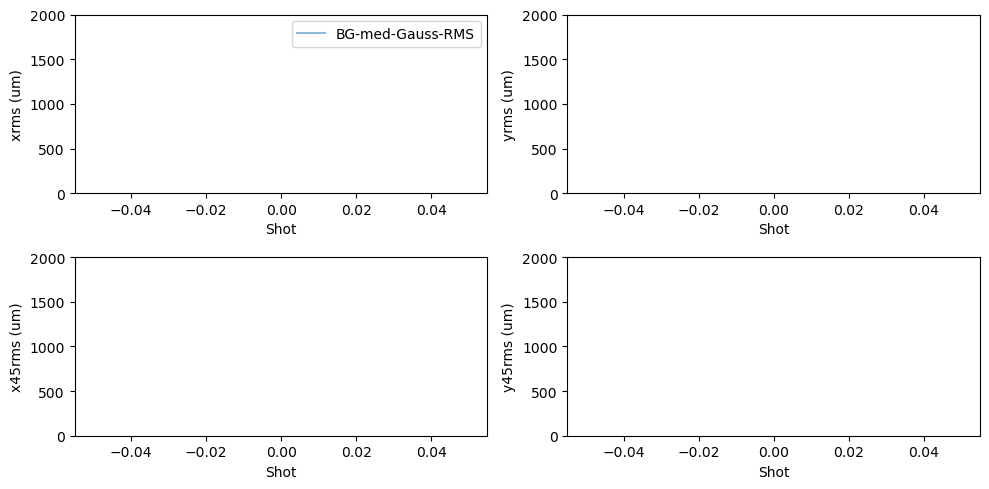

In [33]:
fig,ax=plt.subplots(2,2,figsize=(10,5))
xlim=150
for col in list(cols)[:1]:
    data1 = moments['x_'+ col]
    data2 = moments['y_'+ col]
    data3 = moments['x45_'+ col]
    data4 = moments['y45_'+ col]
    
    # fig.suptitle(col)
    ax[0,0].plot(data1,label=col,alpha=0.5)
    # ax[0,0].set_title('x')
    ax[0,0].set_xlabel('Shot')
    ax[0,0].set_ylabel('xrms (um)')
    ax[0,0].legend()
    ax[0,0].set_ylim([0,2000])
    # ax[0,0].set_xlim([0,xlim])
    
    ax[0,1].plot(data2,label=col,alpha=0.5)
    # ax[0,1].set_title('x')
    ax[0,1].set_xlabel('Shot')
    ax[0,1].set_ylabel('yrms (um)')
    # ax[0,1].legend()
    ax[0,1].set_ylim([0,2000])
    # ax[0,1].set_xlim([0,xlim])
    
    ax[1,0].plot(data3,label=col,alpha=0.5)
    # ax[1,0].set_title('x')
    ax[1,0].set_xlabel('Shot')
    ax[1,0].set_ylabel('x45rms (um)')
    # ax[1,0].legend()
    ax[1,0].set_ylim([0,2000])
    # ax[1,0].set_xlim([0,xlim])
    
    ax[1,1].plot(data4,label=col,alpha=0.5)
    # ax[1,1].set_title('x')
    ax[1,1].set_xlabel('Shot')
    ax[1,1].set_ylabel('y45rms (um)')
    # ax[1,1].legend()
    ax[1,1].set_ylim([0,2000])
    # ax[1,1].set_ylim([0,xlim])
plt.tight_layout()

In [34]:

imgTest = all_img_med_bg_subt[102]
plt.imshow(imgTest,vmax=200)
plt.colorbar()

IndexError: list index out of range

In [ ]:
plt.plot(np.sum(imgTest,axis=1))

In [ ]:
RMS_Calc(np.sum(imgTest,axis=1)).Sigma*pxcal

In [ ]:
RMS_Calc(np.sum(imgTest,axis=0)).Sigma*pxcal

In [ ]:
plt.plot(fit_gauss(np.sum(imgTest,axis=1)).evaluate_gaussian(np.arange(np.shape(imgTest)[1])))
plt.plot(np.sum(imgTest,axis=1))
plt.plot(RMS_Calc(np.sum(imgTest,axis=1)).evaluate_gaussian(np.arange(np.shape(imgTest)[1])))

In [ ]:
moments_stem = 'Gauss-BG-Subt'
cutoff = 750e-6
pxcal_adjustment = 1

In [ ]:
sigma_x = moments_cleaned['x_' + moments_stem]*1e-6
sigma_y = moments_cleaned['y_' + moments_stem]*1e-6
sigma_x45 = moments_cleaned['x45_' + moments_stem]*1e-6
sigma_y45 = moments_cleaned['y45_' + moments_stem]*1e-6

moments_for_opt = pd.DataFrame({})
moments_for_opt['sigma_x'] = sigma_x
moments_for_opt['sigma_y'] = sigma_y
moments_for_opt['sigma_x45'] = sigma_x45
moments_for_opt['sigma_y45'] = sigma_y45

# Plot 
plt.plot(np.array(sigma_x)*pxcal_adjustment,label='x')
plt.plot(np.array(sigma_y)*pxcal_adjustment,label='y')
plt.plot(np.array(sigma_x45)*pxcal_adjustment,label='x45')
plt.plot(np.array(sigma_y45)*pxcal_adjustment,label='y45')
plt.xlabel('Shot')
plt.ylabel('Beam Size (m)')
plt.legend()
# plt.savefig(filepath+'All_Moments_'+nickname+'.png')
plt.show()
# Clean data by removing images that are too big for the frame
# Get an index of images that are too big for the frame
idx_x = np.array(sigma_x) > cutoff/(pxcal_adjustment) #np.shape(image_stack)[2]/2/3 
idx_y = np.array(sigma_y) > cutoff/(pxcal_adjustment) #np.shape(image_stack)[1]/2/3 
idx_x45 = np.array(sigma_x45) > cutoff/(pxcal_adjustment) #np.shape(image_stack)[2]*np.sqrt(2)/2/3 
idx_y45 = np.array(sigma_y45) > cutoff/(pxcal_adjustment) #np.shape(image_stack)[1]*np.sqrt(2)/2/3 

idx_nan = data.isna().any(axis=1).to_numpy()

idx = idx_x + idx_y + idx_x45 + idx_y45 +idx_nan

print('Number of images to cut: ' + str(int(np.sum(idx))))
print('Number of images left: ' + str(int(np.sum(~idx))))


In [ ]:
len(moments)

In [ ]:
data

In [ ]:
len(data.isna().any(axis=1).to_numpy())